# 🧠 Brain Motor Imagery — EDA

**SuperAI SS4 · Level 2 · Hack 4** — rebuild 2026. Notebook นี้ทำ EDA อย่างเดียว (โค้ดจริงอยู่ใน `src/brain_mi/`)

คำถามที่ต้องตอบก่อนวางแผน
1. ข้อมูลมาจากเครื่องอะไร คอลัมน์ 17 ช่องคืออะไร
2. Trial ยาวเท่าไร cue ห่างกันเท่าไร ตัด epoch อย่างไรให้ตรงกับ test
3. Test มาจากคนเดียวกับ train หรือคนใหม่ (within-subject vs cross-subject) — ตัวชี้ขาดของโจทย์นี้
4. สัญญาณมีอะไรให้เรียนรู้จริง ๆ (mu/beta ERD, alpha ตอน rest)
5. Baseline ง่าย ๆ ได้เท่าไรเมื่อแบ่ง fold แบบถูกต้อง

In [1]:
import sys, os, glob, re, collections, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import welch, butter, sosfiltfilt, hilbert
sys.path.insert(0, "../src")
from brain_mi.data import *
ROOT = "../datasets"; ASSETS = "../../../assets"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

## 1. ไฟล์และเครื่องที่ใช้บันทึก

`train/` = บันทึกต่อเนื่องทีละ block (`s{session}_d{day}_p{participant}_{block}`) 4 ไฟล์ต่อ block : ค่าสัญญาณ, timestamp, label, timestamp ของ label
`test/` = trial ที่ตัดมาแล้ว 480 ไฟล์ (ไม่บอกว่าเป็นใคร) · `train_application/` + `test_application/` = ชุดเสริม 180 + 60 trial (ไม่อยู่ใน submission)

In [2]:
blocks = list_blocks(ROOT)
meta = pd.DataFrame([dict(block=b, session=b.split("_")[0], day=b.split("_")[1], subject=b.split("_")[2], blk=int(b.split("_")[3])) for b in blocks])
print("train blocks:", len(blocks), "| subjects:", meta.subject.nunique(), "| sessions:", meta.session.unique().tolist())
print("test trials:", len(glob.glob(f"{ROOT}/test/*.npy")), "| train_application:", len(glob.glob(f"{ROOT}/train_application/train/train/*.npy")), "| test_application:", len(glob.glob(f"{ROOT}/test_application/test_application/*.npy")))
meta.pivot_table(index="subject", columns="session", values="blk", aggfunc="count", fill_value=0).T

train blocks: 191 | subjects: 19 | sessions: ['s1', 's2']
test trials: 480 | train_application: 180 | test_application: 60


subject,p002,p003,p004,p005,p006,p007,p008,p009,p010,p011,p012,p013,p014,p015,p016,p017,p018,p019,p020
session,,,,,,,,,,,,,,,,,,,
s1,3,7,7,6,3,0,4,2,7,7,0,8,3,0,4,0,0,5,6
s2,8,6,2,1,8,7,4,8,8,7,1,4,7,8,8,8,8,8,8


In [3]:
blk = load_block(ROOT, blocks[0])
print("data_time_series", blk["X"].shape, "| labels", blk["y"].shape, "| unique labels", np.unique(blk["y"]))
print("sampling rate (from timestamps): %.2f Hz" % (len(blk["ts"]) / (blk["ts"][-1] - blk["ts"][0])))
cols = EEG_CH + ["AccX","AccY","AccZ","GyrX","GyrY","GyrZ","Battery","Counter","Valid"]
pd.DataFrame(blk["X"][:5], columns=cols).round(2)

data_time_series (53714, 17) | labels (30,) | unique labels [110 120 150]
sampling rate (from timestamps): 248.71 Hz


,Fz,C3,Cz,C4,Pz,PO7,Oz,PO8,AccX,AccY,AccZ,GyrX,GyrY,GyrZ,Battery,Counter,Valid
0,-150246.109375,-139471.312500,-169765.625000,-154886.687500,-34824.109375,4304.049805,-18094.900391,85135.562500,-0.02,0.97,-0.05,0.03,-0.58,-0.24,93.330002,23388.0,1.0
1,-150286.609375,-139561.796875,-169740.859375,-154901.343750,-34824.109375,4278.479980,-18076.660156,85131.796875,-0.02,0.97,-0.06,0.09,-0.64,-0.27,93.330002,23389.0,1.0
2,-149976.375000,-139160.984375,-169704.203125,-154696.609375,-34737.468750,4416.350098,-18048.939453,85218.351562,-0.02,0.97,-0.05,0.09,-0.64,-0.24,93.330002,23390.0,1.0
3,-149873.015625,-138968.937500,-169728.062500,-154640.187500,-34715.660156,4482.330078,-18062.439453,85243.843750,-0.02,0.97,-0.05,0.18,-0.70,-0.15,93.330002,23391.0,1.0
4,-150035.109375,-139166.796875,-169765.000000,-154757.765625,-34772.261719,4406.779785,-18088.910156,85188.132812,-0.02,0.97,-0.05,0.24,-0.79,-0.15,93.330002,23392.0,1.0


17 คอลัมน์ตรงกับ **g.tec Unicorn Hybrid Black** เป๊ะ : EEG 8 ช่อง (Fz, C3, Cz, C4, Pz, PO7, Oz, PO8) + accelerometer 3 + gyroscope 3 + battery + sample counter + validation ที่ 250 Hz
EEG เป็น DC-coupled จึงมี offset ระดับ −150,000 µV และลอย (drift) ตลอดเวลา — ต้อง high-pass ก่อนเสมอ

## 2. โครงสร้างเวลาของ block : cue ทุก 7 วินาที, 30 trial ต่อ block

In [4]:
rows = []
for b in blocks:
    k = load_block(ROOT, b); gaps = np.diff(k["lt"])
    rows.append(dict(block=b, n_samples=len(k["X"]), duration_s=k["ts"][-1]-k["ts"][0], n_cues=len(k["y"]), cue_gap_min=gaps.min(), cue_gap_max=gaps.max(),
                     first_cue_s=k["lt"][0]-k["ts"][0], tail_after_last_cue_s=k["ts"][-1]-k["lt"][-1], counter_jumps=int((np.diff(k["X"][:,COL_COUNTER])!=1).sum()),
                     **{f"n{c}": int((k["y"]==c).sum()) for c in CLASSES}))
tim = pd.DataFrame(rows)
display(tim.describe().T.round(2))
print("blocks ที่ผิดปกติ:"); display(tim[(tim.n_cues!=30)|(tim.cue_gap_max>7.5)][["block","n_cues","cue_gap_max","tail_after_last_cue_s"]])

,count,mean,std,min,25%,50%,75%,max
n_samples,191.0,58034.52,6259.19,45993.00,56334.00,57147.00,58311.00,135651.00
duration_s,191.0,231.96,24.99,185.67,225.02,228.47,233.07,542.32
n_cues,191.0,30.13,2.20,25.00,30.00,30.00,30.00,60.00
cue_gap_min,191.0,6.99,0.00,6.96,6.99,6.99,6.99,7.00
cue_gap_max,191.0,7.21,2.70,7.00,7.01,7.01,7.02,44.33
first_cue_s,191.0,13.31,3.42,0.33,11.78,12.97,14.91,39.56
tail_after_last_cue_s,191.0,14.58,11.37,1.32,10.33,13.05,16.17,92.21
counter_jumps,191.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
n110,191.0,10.04,0.74,8.00,10.00,10.00,10.00,20.00
n120,191.0,10.04,0.74,8.00,10.00,10.00,10.00,20.00


blocks ที่ผิดปกติ:


,block,n_cues,cue_gap_max,tail_after_last_cue_s
1,s1_d2_p002_003,60,44.333268,73.349954
25,s1_d2_p006_008,25,7.008546,5.655526
77,s2_d2_p002_006,29,7.010548,32.729249


In [5]:
seqs = collections.Counter(tuple(load_block(ROOT, b)["y"][:30].tolist()) for b in blocks)
print("ลำดับ label ที่ต่างกันทั้งหมด:", len(seqs))
for s, n in seqs.most_common(): print(n, "blocks :", s)

ลำดับ label ที่ต่างกันทั้งหมด: 3
189 blocks : (120, 110, 150, 150, 120, 110, 120, 110, 150, 150, 120, 110, 120, 150, 110, 150, 120, 110, 120, 110, 150, 150, 120, 110, 150, 120, 110, 150, 120, 110)
1 blocks : (120, 110, 150, 150, 120, 110, 120, 110, 150, 150, 120, 110, 120, 150, 110, 150, 120, 110, 120, 110, 150, 150, 120, 110, 150)
1 blocks : (110, 150, 150, 120, 110, 120, 110, 150, 150, 120, 110, 120, 150, 110, 150, 120, 110, 120, 110, 150, 150, 120, 110, 150, 120, 110, 150, 120, 110)


**ลำดับ cue ใน block เป็นลำดับตายตัว** (190/191 block เหมือนกันหมด อีก 1 block คือลำดับเดิมที่หาย cue แรกไป) → เก็บไว้เป็นข้อสังเกตในหัวข้อ 5

## 3. สัญญาณดิบ 1 block : drift, 50 Hz, artifact

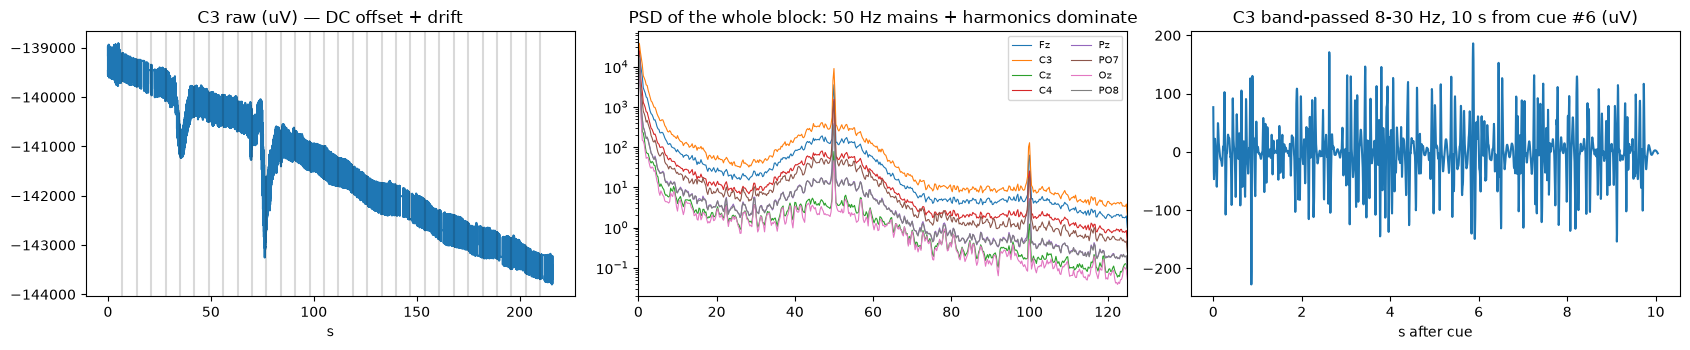

In [6]:
X = blk["X"][:, :8]; t = (blk["ts"] - blk["ts"][0])
fig, ax = plt.subplots(1, 3, figsize=(17, 3.6))
ax[0].plot(t, X[:, 1]); ax[0].set_title("C3 raw (uV) — DC offset + drift"); ax[0].set_xlabel("s")
for lt in blk["lt"]: ax[0].axvline(lt - blk["ts"][0], color="k", alpha=.15)
f, Pxx = welch(X - X.mean(0), fs=FS, nperseg=1000, axis=0)
for ci in range(8): ax[1].semilogy(f, Pxx[:, ci], label=EEG_CH[ci], lw=.8)
ax[1].set_xlim(0, 125); ax[1].set_title("PSD of the whole block: 50 Hz mains + harmonics dominate"); ax[1].legend(ncol=2, fontsize=7)
sos = butter(4, [8, 30], btype="band", fs=FS, output="sos"); Xf = sosfiltfilt(sos, X, axis=0)
i0 = int(np.searchsorted(blk["ts"], blk["lt"][5])); ax[2].plot(t[i0:i0+2500] - t[i0], Xf[i0:i0+2500, 1]); ax[2].set_title("C3 band-passed 8-30 Hz, 10 s from cue #6 (uV)"); ax[2].set_xlabel("s after cue")
fig.tight_layout(); fig.savefig(f"{ASSETS}/brain_mi_raw_block.png", dpi=110)

## 4. ตัด epoch [cue, cue+7 s) และดูว่าคลาสต่างกันตรงไหน

train epochs: (5737, 8, 1750) | test: (480, 8, 1750) | class counts: Counter({150: 1919, 120: 1917, 110: 1901})


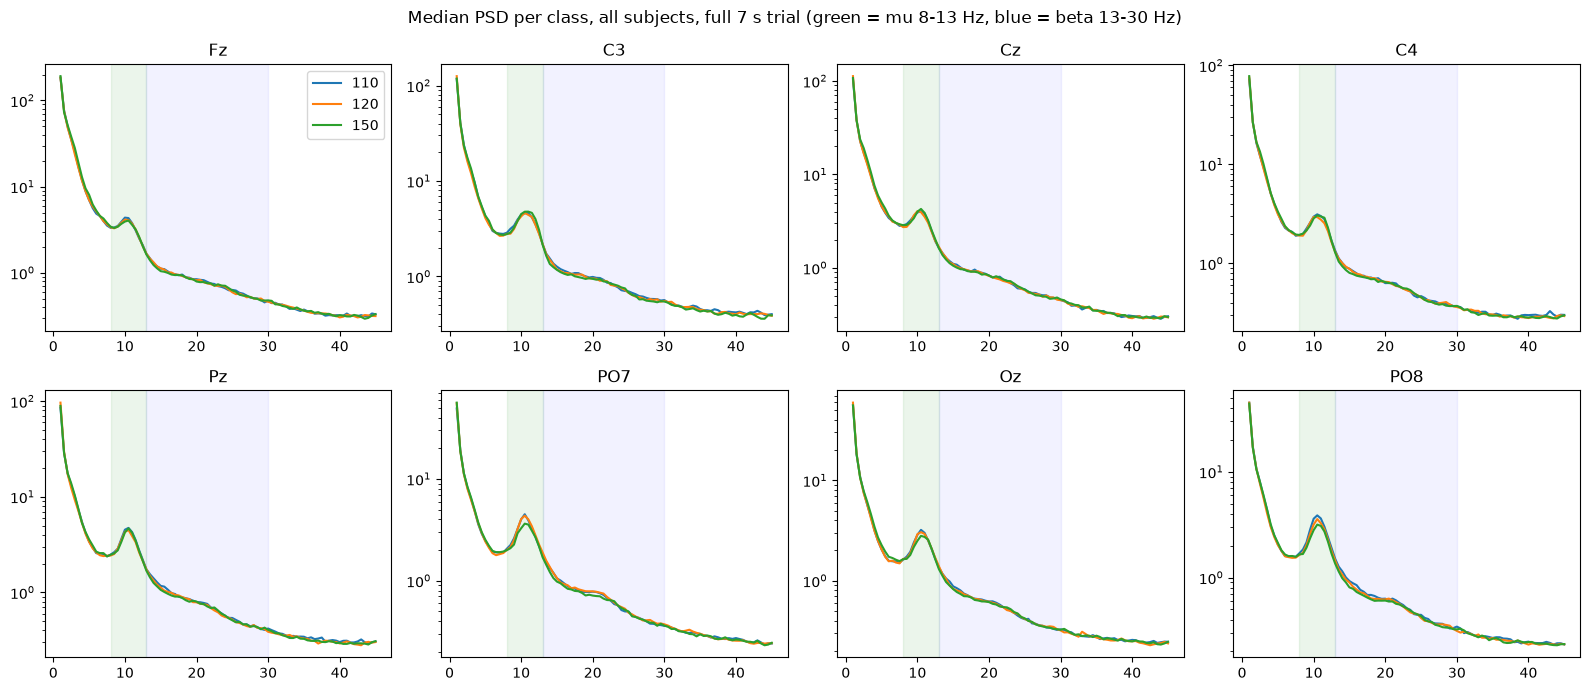

In [7]:
tr = load_train_epochs(ROOT); te = load_test_epochs(ROOT)
print("train epochs:", tr.X.shape, "| test:", te.X.shape, "| class counts:", collections.Counter(tr.y.tolist()))
Xd = tr.X - tr.X.mean(2, keepdims=True); y = tr.y
f, P = welch(Xd, fs=FS, nperseg=500, axis=-1); m = (f >= 1) & (f <= 45)
LAB = {110: "110", 120: "120", 150: "150"}
fig, ax = plt.subplots(2, 4, figsize=(16, 7))
for ci, a in enumerate(ax.ravel()):
    for lab in CLASSES: a.semilogy(f[m], np.median(P[y == lab, ci][:, m], 0), label=LAB[lab])
    a.set_title(EEG_CH[ci]); a.axvspan(8, 13, alpha=.08, color="g"); a.axvspan(13, 30, alpha=.05, color="b")
ax[0, 0].legend(); fig.suptitle("Median PSD per class, all subjects, full 7 s trial (green = mu 8-13 Hz, blue = beta 13-30 Hz)"); fig.tight_layout(); fig.savefig(f"{ASSETS}/brain_mi_psd_by_class.png", dpi=110)

In [8]:
mu = P[:, :, (f >= 8) & (f < 13)].mean(-1); beta = P[:, :, (f >= 13) & (f < 30)].mean(-1)
tab = pd.DataFrame({f"mu {c} vs 150": [np.log(np.median(mu[y == c, ci]) / np.median(mu[y == 150, ci])) for ci in range(8)] for c in (110, 120)} |
                   {f"beta {c} vs 150": [np.log(np.median(beta[y == c, ci]) / np.median(beta[y == 150, ci])) for ci in range(8)] for c in (110, 120)}, index=EEG_CH).round(3)
display(tab)
print("lateralisation log(mu C3) - log(mu C4) per class:", {c: round(float(np.median(np.log(mu[y == c, 1]) - np.log(mu[y == c, 3]))), 3) for c in CLASSES})

,mu 110 vs 150,mu 120 vs 150,beta 110 vs 150,beta 120 vs 150
Fz,0.045,0.033,0.025,0.020
C3,-0.055,-0.075,0.040,0.043
Cz,-0.022,-0.035,0.032,0.013
C4,-0.006,-0.025,0.038,0.005
Pz,0.047,0.022,0.042,-0.001
PO7,0.096,0.099,0.018,0.037
Oz,0.079,0.045,0.042,0.029
PO8,0.159,0.090,0.053,0.025


lateralisation log(mu C3) - log(mu C4) per class: {110: 0.327, 120: 0.354, 150: 0.348}


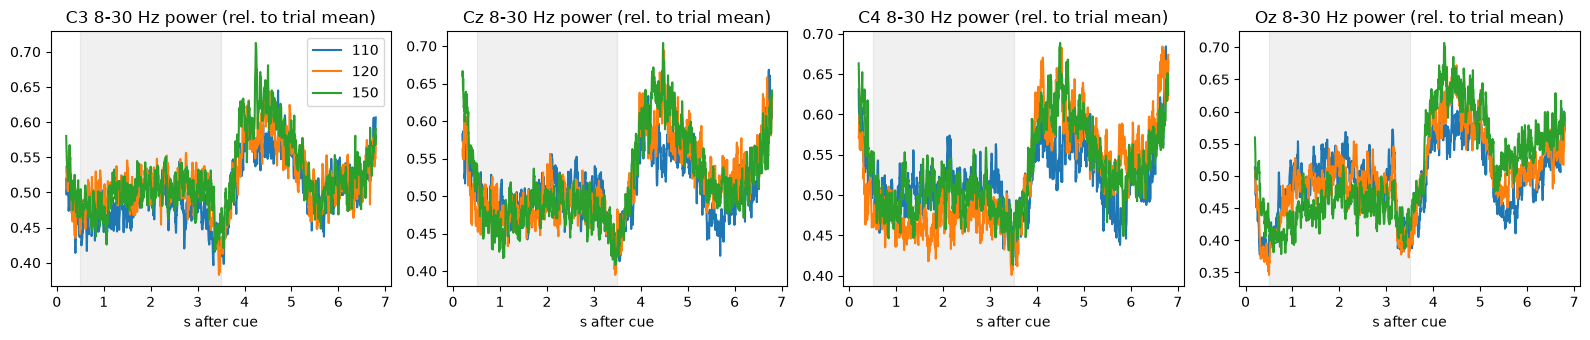

In [9]:
sos = butter(4, [8, 30], btype="band", fs=FS, output="sos"); env = np.abs(hilbert(sosfiltfilt(sos, Xd, axis=-1), axis=-1)) ** 2
tt = np.arange(TRIAL_SAMPLES) / FS
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5))
for k, ci in enumerate([1, 2, 3, 6]):
    for lab in CLASSES:
        e = env[y == lab, ci][:, 50:-50]; e = e / e.mean(1, keepdims=True); ax[k].plot(tt[50:-50], np.median(e, 0), label=LAB[lab])
    ax[k].set_title(f"{EEG_CH[ci]} 8-30 Hz power (rel. to trial mean)"); ax[k].set_xlabel("s after cue"); ax[k].axvspan(0.5, 3.5, alpha=.06, color="k")
ax[0].legend(); fig.tight_layout(); fig.savefig(f"{ASSETS}/brain_mi_erd_timecourse.png", dpi=110)

สิ่งที่เห็น
- **C3 mu ลดลง (ERD) ทั้ง 110 และ 120 เทียบกับ 150** → 150 คือ *rest* ค่อนข้างแน่ และ MI ทั้งสองข้างทำให้ mu ที่ C3 ตก
- **occipital (PO7/Oz/PO8) มี alpha *สูงกว่า* ตอน MI** — ตอน rest alpha กลับต่ำ (คนน่าจะมองจอ/ตาเปิดตอน rest) → แยก rest ออกได้จาก occipital alpha
- **110 vs 120 แทบไม่ต่างกันเลยเมื่อรวมทุกคน** (lateralisation C3−C4 เท่ากันทั้งสามคลาส) — ซ้าย/ขวาคือส่วนที่ยากจริง
- ERD เริ่ม ~0.5 s หลัง cue และที่ ~3.5–4 s power กลับขึ้นพร้อมกันทุกคลาส (น่าจะเป็นช่วงจบ task/feedback ของ paradigm) → หน้าต่าง **0.5–3.5 s** (แถบเทา) น่าจะดีกว่าใช้ทั้ง 7 s

In [10]:
rows = []
for s, g in tr.meta.groupby("subject"):
    i = g.index.values; ys = y[i]; oz = np.log(mu[i, 6]); c3 = np.log(mu[i, 1]); lat = np.log(mu[i, 1]) - np.log(mu[i, 3])
    rows.append(dict(subject=s, n=len(i), Oz_alpha_MI_minus_rest=oz[ys != 150].mean() - oz[ys == 150].mean(),
                     C3_mu_rest_minus_MI=c3[ys == 150].mean() - c3[ys != 150].mean(), lat_110_minus_120=lat[ys == 110].mean() - lat[ys == 120].mean()))
persub = pd.DataFrame(rows).set_index("subject").round(3)
display(persub.T)
print("สัดส่วนคนที่เครื่องหมายเป็นไปตามทฤษฎี:", (persub > 0).mean().round(2).to_dict())

subject,p002,p003,p004,p005,p006,p007,p008,p009,p010,p011,p012,p013,p014,p015,p016,p017,p018,p019,p020
n,359.000,389.000,270.000,210.000,325.000,210.000,240.000,300.000,450.000,416.000,30.000,360.000,300.000,238.000,354.000,240.000,240.000,390.000,416.000
Oz_alpha_MI_minus_rest,0.160,0.070,-0.026,-0.111,-0.033,-0.285,0.017,0.281,0.144,0.177,0.036,0.107,0.070,-0.201,-0.065,0.044,0.273,-0.255,0.153
C3_mu_rest_minus_MI,-0.082,-0.158,-0.044,0.059,0.075,0.018,-0.055,-0.008,-0.093,-0.136,-0.169,0.126,0.088,0.144,-0.032,0.068,0.018,0.407,-0.034
lat_110_minus_120,-0.054,0.074,-0.001,0.015,0.001,0.074,0.006,-0.010,-0.120,-0.077,0.171,-0.079,-0.046,0.039,0.034,-0.040,-0.060,-0.007,-0.015


สัดส่วนคนที่เครื่องหมายเป็นไปตามทฤษฎี: {'n': 1.0, 'Oz_alpha_MI_minus_rest': 0.63, 'C3_mu_rest_minus_MI': 0.47, 'lat_110_minus_120': 0.42}


ทิศทางของ feature **ไม่คงที่ข้ามคน** (ประมาณครึ่งหนึ่งของคนกลับด้าน) — นี่คือเหตุผลที่โมเดลรวม (pooled) ทำได้แย่ และทำไมต้องมี alignment ต่อคน/ต่อ session

## 5. Test มาจากใคร? — ใช้ DC offset + sample counter เป็นลายนิ้วมือ

DC offset ของ electrode แต่ละช่องเป็นลายนิ้วมือของ "การสวมหมวกครั้งนั้น" ส่วน counter นับ +1 ต่อ sample ตั้งแต่เริ่มบันทึก
→ ถ้า test trial 2 อันมี counter ห่างกัน 1750 พอดีและ DC ใกล้กัน = trial ติดกันใน block เดียวกัน

In [11]:
R = reconstruct_test_blocks(te.meta)
print("test blocks ที่ประกอบกลับได้:", R.blk.nunique(), "| ขนาด:", R.groupby("blk").size().value_counts().to_dict())
R["tsess"] = np.where(R.battery < 70, "session A (batt 66.7)", "session B (batt 100→86.7)")
display(R.groupby(["tsess", "blk"]).agg(n=("id", "size"), counter_start=("counter", "min"), counter_end=("counter", "max"), battery=("battery", "mean")).round(1))

test blocks ที่ประกอบกลับได้: 16 | ขนาด: {30: 16}


n  counter_start  counter_end  battery
tsess                     blk                                         
session A (batt 66.7)     1    30        29881.0      80659.0     66.7
                          3    30        97979.0     148753.0     66.7
                          5    30       164983.0     215759.0     66.7
                          7    30       231217.0     281989.0     66.7
                          9    30       320401.0     371174.0     66.7
                          11   30       407554.0     458326.0     66.7
                          13   30       480201.0     530971.0     66.7
                          15   30       551506.0     602290.0     66.7
session B (batt 100→86.7) 0    30        15668.0      66450.0    100.0
                          2    30        82706.0     133491.0     96.3
                          4    30       147744.0     198528.0     93.3
                          6    30       210414.0     261192.0     93.3
                          8    30       305540.0     356315.0     93.3
                          10   30       369435.0     420216.0     93.3
                          12   30       434338.0     485111.0     93.3
                          14   30       497361.0     548136.0     89.4

In [12]:
# ใกล้ session ไหนใน train ที่สุด? (ระยะ DC ปรับสเกลด้วย drift ภายใน block)
drift = np.array([498, 620, 613, 606, 768, 801, 865, 463.0])
trdc = tr.meta.assign(dc=list((tr.X.mean(2)))).groupby("sess").dc.apply(lambda s: np.mean(np.stack(s), 0))
TRc = np.stack(trdc.values); TEc = np.stack(R.dc.values)
d = np.sqrt((((TEc[:, None] - TRc[None]) / drift) ** 2).sum(-1))
R["nn_train_sess"] = trdc.index.values[d.argmin(1)]; R["nn_dist"] = d.min(1)
same = []  # calibration: ระยะจาก block ไป block อื่นใน session เดียวกัน
blkdc = tr.meta.assign(dc=list(tr.X.mean(2))).groupby("block").agg(sess=("sess", "first"), dc=("dc", lambda s: np.mean(np.stack(s), 0)))
B = np.stack(blkdc.dc.values); dd = np.sqrt((((B[:, None] - B[None]) / drift) ** 2).sum(-1)); np.fill_diagonal(dd, np.inf)
for i, s in enumerate(blkdc.sess.values):
    msk = blkdc.sess.values == s
    if msk.sum() > 1: same.append(dd[i][msk].min())
print("train: ระยะไป block อื่นใน session เดียวกัน (median / p90): %.1f / %.1f" % (np.median(same), np.quantile(same, .9)))
display(R.groupby("tsess").agg(n=("id", "size"), nearest_train_session=("nn_train_sess", lambda s: s.value_counts().index[0]), dist_median=("nn_dist", "median")).round(1))

train: ระยะไป block อื่นใน session เดียวกัน (median / p90): 10.9 / 48.2


,n,nearest_train_session,dist_median
tsess,,,
session A (batt 66.7),240,s1_d3_p013,48.7
session B (batt 100→86.7),240,s1_d4_p020,142.2


- test = **16 block × 30 trial ครบถ้วน จาก 2 session** (แบตเตอรี่ 66.7 ทั้งชุด กับ 100→86.7 ทั้งชุด)
- ระยะ DC ไป session ที่ใกล้ที่สุดใน train (34 และ 118) มากกว่าระยะระหว่าง block ใน session เดียวกัน (median 11) มาก และ session ที่ใกล้ที่สุดก็มี block ครบ 8 อยู่ใน train แล้ว
- **สรุป : test คือ 2 session ของคนที่ไม่อยู่ใน train → โจทย์นี้วัด cross-subject generalisation** (สอดคล้องกับ leaderboard เดิมที่ทุกทีมได้ 0.26–0.52)

### ⚠️ ข้อสังเกตเรื่อง leak (ไม่ใช้ในการเทรน)

เมื่อประกอบ block กลับได้พร้อมลำดับ และลำดับ cue เป็นลำดับตายตัว → label ของ test "อ่านออก" ได้จาก metadata ล้วน ๆ
ตรวจสอบว่าสมมติฐานนี้จริงไหมด้วยสรีรวิทยา : ถ้า label จากลำดับถูก, occipital alpha ตอน MI ต้องสูงกว่า rest (เหมือน train)

In [13]:
R["leak_label"] = np.array(CUE_SEQUENCE)[R.pos.values]
lab = R.set_index("id").leak_label.reindex(te.meta.id).values; blkid = R.set_index("id").blk.reindex(te.meta.id).values
f2, P2 = welch(te.X - te.X.mean(2, keepdims=True), fs=FS, nperseg=500, axis=-1); mu2 = np.log(P2[:, :, (f2 >= 8) & (f2 < 13)].mean(-1))
def oz_effect(labels): return np.mean([mu2[(blkid == b) & (labels != 150), 6].mean() - mu2[(blkid == b) & (labels == 150), 6].mean() for b in np.unique(blkid)])
rng = np.random.default_rng(0); null = []
for _ in range(300):
    l2 = lab.copy()
    for b in np.unique(blkid): i = np.where(blkid == b)[0]; l2[i] = rng.permutation(l2[i])
    null.append(oz_effect(l2))
print("Oz alpha (MI − rest) ด้วย label จากลำดับ cue: %.3f | null (สลับ label ใน block): %.3f ± %.3f  → z = %.1f" % (oz_effect(lab), np.mean(null), np.std(null), (oz_effect(lab) - np.mean(null)) / np.std(null)))

Oz alpha (MI − rest) ด้วย label จากลำดับ cue: 0.216 | null (สลับ label ใน block): -0.001 ± 0.032  → z = 6.8


z ≈ 7 → ลำดับ cue ใน test เป็นลำดับเดียวกับ train จริง (ผู้จัดลบ counter ทิ้งเฉพาะในชุด `*_application` เท่านั้น)
**นโยบายของรอบนี้ :** ใช้ label ชุดนี้เป็น *oracle สำหรับวัดผล* โมเดลจริงบนเครื่องเราเท่านั้น ไม่ส่งขึ้น leaderboard (ดู README)

## 6. ชุด `*_application` คืออะไร

In [14]:
A, B_ = load_application_epochs(ROOT)
print("train_application:", A.X.shape, collections.Counter(A.y.tolist()), "| test_application:", B_.X.shape)
raw = np.load(sorted(glob.glob(f"{ROOT}/train_application/train/train/*.npy"))[0]); print("counter column ในชุดนี้:", np.unique(raw[:, COL_COUNTER]))
Ac = np.stack(A.meta.dc.values).mean(0); Bc = np.stack(B_.meta.dc.values).mean(0)
print("ระยะ DC train_app ↔ test_app: %.1f | train_app ↔ test session A/B: %.1f / %.1f | ↔ train session ใกล้สุด: %.1f" % (
    np.sqrt((((Ac - Bc) / drift) ** 2).sum()), *[np.sqrt((((Ac - np.stack(R[R.tsess == s].dc.values).mean(0)) / drift) ** 2).sum()) for s in sorted(R.tsess.unique())],
    np.sqrt((((Ac - TRc) / drift) ** 2).sum(-1)).min()))

train_application: (180, 8, 1750) Counter({110: 60, 120: 60, 150: 60}) | test_application: (60, 8, 1750)
counter column ในชุดนี้: [-1.]
ระยะ DC train_app ↔ test_app: 0.6 | train_app ↔ test session A/B: 160.7 / 198.0 | ↔ train session ใกล้สุด: 42.3


`train_application` (180 trial มี label) และ `test_application` (60) มาจาก **session เดียวกันอีก session หนึ่งที่ไม่มีใน train และไม่ใช่ test** และ counter ถูกลบเป็น −1
→ ใช้ `train_application` เป็น **validation domain ที่สอง** (คนใหม่จริง ๆ 180 trial) ได้ดีมาก และ/หรือรวมเป็น train ตอนท้าย

## 7. Baseline ที่แบ่ง fold ให้ตรงกับโจทย์ (GroupKFold ตาม subject)

In [15]:
from sklearn.linear_model import LogisticRegression; from sklearn.pipeline import make_pipeline; from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold; from sklearn.metrics import accuracy_score, f1_score
from pyriemann.estimation import Covariances; from pyriemann.tangentspace import TangentSpace
def euclid_align(Xc, groups):
    out = np.empty_like(Xc)
    for g in np.unique(groups):
        i = groups == g; Cm = np.mean([x @ x.T / x.shape[1] for x in Xc[i]], 0); w, V = np.linalg.eigh(Cm); out[i] = np.einsum("ij,njt->nit", V @ np.diag(w ** -0.5) @ V.T, Xc[i])
    return out
Xf = sosfiltfilt(butter(4, [8, 30], btype="band", fs=FS, output="sos"), Xd, axis=-1)[:, :, int(0.5 * FS):int(3.5 * FS)].astype(np.float32)
res = []
for name, groups, Xin in [("split by SUBJECT", tr.meta.subject.values, Xf), ("split by SUBJECT + EA per session", tr.meta.subject.values, euclid_align(Xf, tr.meta.sess.values)),
                          ("split by BLOCK (subject seen)", tr.meta.block.values, Xf), ("split by BLOCK + EA per session", tr.meta.block.values, euclid_align(Xf, tr.meta.sess.values))]:
    acc = []; f1 = []
    for a, b in GroupKFold(5).split(Xin, y, groups):
        clf = make_pipeline(Covariances("oas"), TangentSpace(), StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xin[a], y[a]); p = clf.predict(Xin[b])
        acc.append(accuracy_score(y[b], p)); f1.append(f1_score(y[b], p, average="macro"))
    res.append(dict(setting=name, acc=np.mean(acc), acc_std=np.std(acc), macro_f1=np.mean(f1)))
pd.DataFrame(res).round(3)

,setting,acc,acc_std,macro_f1
0,split by SUBJECT,0.434,0.040,0.423
1,split by SUBJECT + EA per session,0.448,0.065,0.444
2,split by BLOCK (subject seen),0.484,0.021,0.481
3,split by BLOCK + EA per session,0.493,0.021,0.491


TS+LR (8–30 Hz, 0.5–3.5 s) ได้ราว **0.44 เมื่อคนใน test ไม่เคยเห็น** และ ~0.49 เมื่อเห็นคนแล้ว (chance = 0.33)
ตารางเต็ม (หน้าต่าง/แบนด์/โมเดล DL) อยู่ใน README — ข้อสรุปเหมือนกัน : ยังไม่มีอะไรเกิน ~0.45 cross-subject จึงต้องไปที่ alignment + hierarchical + ensemble ตามแผน